In [1]:
import pandas as pd
import numpy as np
from optbinning import OptimalBinning, BinningProcess
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

master = pd.read_parquet('../data/processed/master_table.parquet')

# 需要剔除的列：客户ID、标签，不能放进特征集
DROP_COLS = ['SK_ID_CURR', 'TARGET']
X = master.drop(columns=DROP_COLS)
y = master['TARGET']

print(f"Shape: {X.shape}")
print(f"Target rate: {y.mean():.3f}")

Shape: (307511, 164)
Target rate: 0.081


In [2]:
import pandas as pd
import numpy as np
from optbinning import OptimalBinning, BinningProcess
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

master = pd.read_parquet('../data/processed/master_table.parquet')

# 需要剔除的列：客户ID、标签，不能放进特征集
DROP_COLS = ['SK_ID_CURR', 'TARGET']
X = master.drop(columns=DROP_COLS)
y = master['TARGET']

print(f"Shape: {X.shape}")
print(f"Target rate: {y.mean():.3f}")

Shape: (307511, 164)
Target rate: 0.081


In [3]:
# 原本计划使用审批日期划分时间外样本；HomeCredit数据集缺少真实申请时间，无法按时间切分
# 因此采用分层随机划分：训练集80%，随机留出测试集20%

from sklearn.model_selection import train_test_split

X_train, X_oot, y_train, y_oot = train_test_split(
    X, y,
    test_size=0.2,        # 20%划分为测试集，80%训练集
    random_state=42,      # 随机种子，固定划分结果，保证代码复现
    stratify=y            # 分层抽样！保证训练集、测试集坏账比例和全集保持一致
)

print(f"Train: {X_train.shape}, default rate: {y_train.mean():.3f}")
print(f"Holdout:   {X_oot.shape},   default rate: {y_oot.mean():.3f}")

Train: (246008, 164), default rate: 0.081
Holdout:   (61503, 164),   default rate: 0.081


In [4]:
# 类别特征预处理，用于后续IV计算
# 类别映射规则只能基于训练集生成，保存映射文件，保证留出集编码方式和训练集完全统一
# 防止测试集出现训练集未见过的类别，避免预测不一致

X_train_enc = X_train.copy()
X_oot_enc   = X_oot.copy()

cat_cols = X_train.select_dtypes(include='object').columns.tolist()

category_maps = {}

for col in cat_cols:
    cats = sorted(X_train[col].fillna('Missing').unique().tolist())
    category_maps[col] = cats
    
    X_train_enc[col] = pd.Categorical(
        X_train[col].fillna('Missing'), categories=cats
    ).codes.astype(float)
    
    # 留出集：使用【训练集定义好的类别】编码，保证规则一致
    X_oot_enc[col] = pd.Categorical(
        X_oot[col].fillna('Missing'), categories=cats
    ).codes.astype(float)

# 将分类特征的类别清单保存为json文件，线上预测时复用这套映射规则
with open('../models/category_maps.json', 'w') as f:
    json.dump(category_maps, f)

print(f"Encoded {len(cat_cols)} categorical columns, saved category_maps.json")
print(X_train_enc[cat_cols[:3]].dtypes) # 校验：确认编码后转为浮点型

Encoded 16 categorical columns, saved category_maps.json
NAME_CONTRACT_TYPE    float64
CODE_GENDER           float64
FLAG_OWN_CAR          float64
dtype: object


In [5]:
def calculate_iv(X, y, features, categorical_cols):
    iv_results = []
    for col in features:
        try:
            x_col = X[col].astype('float64')
            # 重点：分类特征即使编码成数字，依然告诉工具按分类处理，不要当成连续变量分箱
            dtype = 'categorical' if col in categorical_cols else 'numerical'
            ob = OptimalBinning(name=col, dtype=dtype, solver='cp')
            ob.fit(x_col.values, y.values)
            binning_table = ob.binning_table.build()
            iv = binning_table['IV'].iloc[-1]
            iv_results.append({'feature': col, 'iv': round(iv, 4)})
        except Exception as e:
            print(f"ERROR on {col}: {e}")
            # 异常特征IV赋值0，代表无预测能力
            iv_results.append({'feature': col, 'iv': 0.0})
    return pd.DataFrame(iv_results).sort_values('iv', ascending=False)

# 分类特征按类别处理，不能把编码后的数字当作连续数值
iv_df = calculate_iv(X_train_enc, y_train, X_train_enc.columns.tolist(), cat_cols)
print(iv_df.head(20))

                         feature      iv
41                  EXT_SOURCE_3  0.3353
40                  EXT_SOURCE_2  0.3190
39                  EXT_SOURCE_1  0.1480
127      bureau_days_credit_mean  0.1233
16                 DAYS_EMPLOYED  0.1158
8                AMT_GOODS_PRICE  0.0925
15                    DAYS_BIRTH  0.0903
26               OCCUPATION_TYPE  0.0784
38             ORGANIZATION_TYPE  0.0735
147       inst_late_payment_rate  0.0651
140           prev_approval_rate  0.0627
153                 cc_util_mean  0.0621
6                     AMT_CREDIT  0.0592
10              NAME_INCOME_TYPE  0.0560
134           prev_refused_count  0.0556
121          bureau_active_count  0.0547
29   REGION_RATING_CLIENT_W_CITY  0.0516
145      inst_amt_underpaid_mean  0.0497
123              bureau_debt_sum  0.0482
28          REGION_RATING_CLIENT  0.0482


Selected by IV (>= 0.02): 81
Dropped by IV  (< 0.02): 83


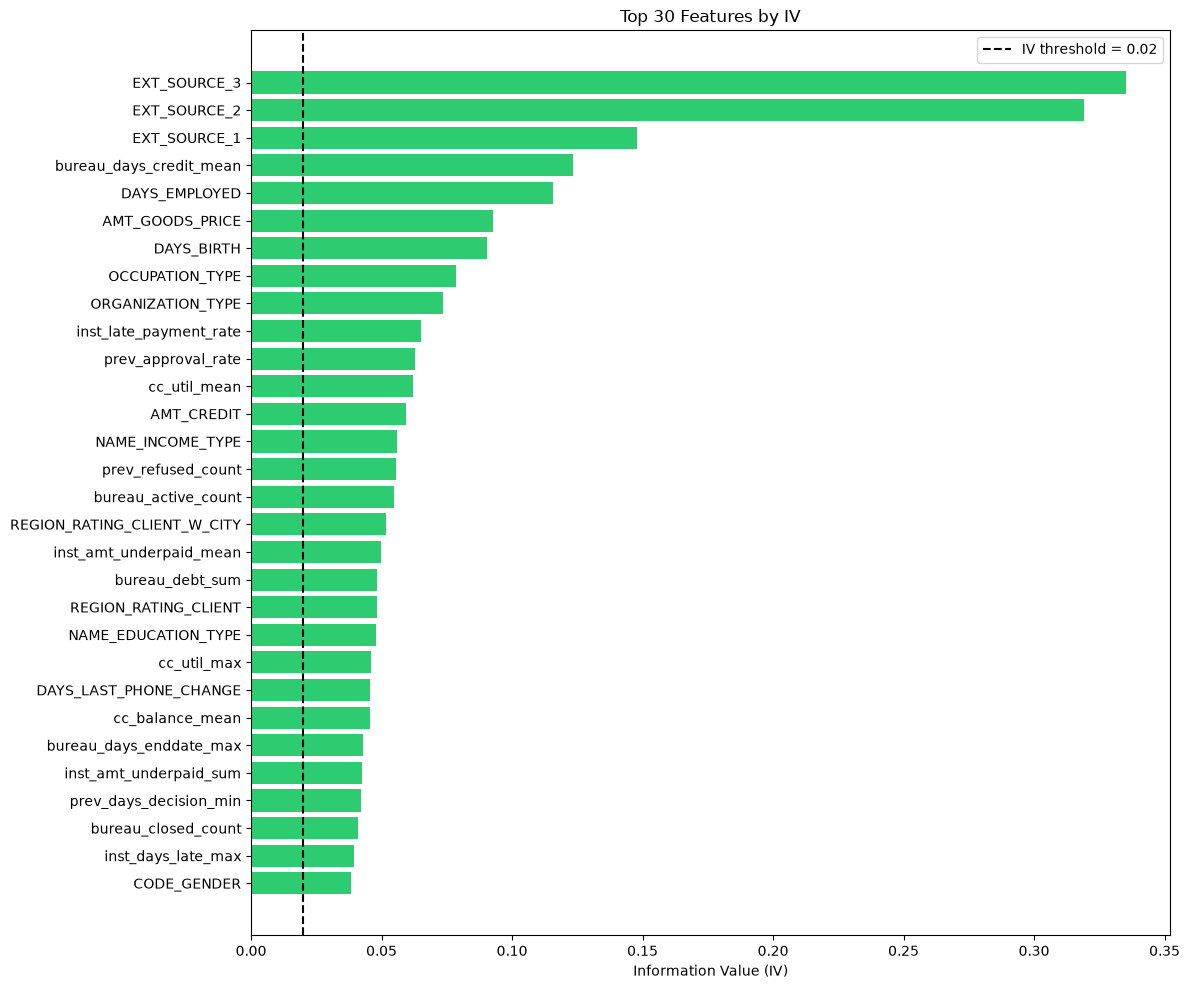

In [6]:
# IV筛选阈值 0.02，风控行业通用最低标准
iv_threshold = 0.02
#iv_threshold = 0.03  #备选阈值，可以切换测试

selected_by_iv = iv_df[iv_df['iv'] >= iv_threshold]['feature'].tolist()
dropped_by_iv = iv_df[iv_df['iv'] <  iv_threshold]['feature'].tolist()

print(f"Selected by IV (>= {iv_threshold}): {len(selected_by_iv)}")
print(f"Dropped by IV  (< {iv_threshold}): {len(dropped_by_iv)}")

plt.figure(figsize=(12, 10))
plot_df = iv_df.head(30)
colors = ['#2ecc71' if iv >= iv_threshold else '#e74c3c' for iv in plot_df['iv']]
plt.barh(plot_df['feature'], plot_df['iv'], color=colors)
plt.axvline(x=iv_threshold, color='black', linestyle='--', label=f'IV threshold = {iv_threshold}')
plt.xlabel('Information Value (IV)')
plt.title('Top 30 Features by IV')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
variable_names = selected_by_iv
dtypes = []

for col in variable_names:
    dtypes.append('categorical' if X_train[col].dtype == 'object' else 'numerical')

binning_process = BinningProcess(
    variable_names=variable_names,
    categorical_variables=[c for c, d in zip(variable_names, dtypes) if d == 'categorical']
)

# 基于训练集执行最优分箱学习，只能用训练集，杜绝数据泄露
binning_process.fit(X_train_enc[variable_names], y_train)

# 对训练集做WOE转换
X_train_woe = binning_process.transform(X_train_enc[variable_names], metric='woe')
# 使用训练集学到的分箱规则，对随机留出测试集做WOE转换（规则复用，不能重新分箱）
X_oot_woe   = binning_process.transform(X_oot_enc[variable_names], metric='woe')

print(f"WoE transformed train shape: {X_train_woe.shape}")
X_train_woe.head()

WoE transformed train shape: (246008, 81)


,EXT_SOURCE_3,EXT_SOURCE_2,EXT_SOURCE_1,bureau_days_credit_mean,DAYS_EMPLOYED,AMT_GOODS_PRICE,DAYS_BIRTH,OCCUPATION_TYPE,ORGANIZATION_TYPE,inst_late_payment_rate,...,OWN_CAR_AGE,NONLIVINGAREA_AVG,NONLIVINGAREA_MEDI,NONLIVINGAREA_MODE,bureau_bb_dpd_months_sum,BASEMENTAREA_AVG,HOUSETYPE_MODE,BASEMENTAREA_MEDI,BASEMENTAREA_MODE,pos_completed_count
181648,0.595479,-0.386393,-0.14801,0.236933,-0.343461,-0.017004,-0.235756,-0.293566,-0.040140,0.194044,...,0.000000,0.116766,0.123037,0.126762,0.090541,0.368281,0.159506,0.371336,0.357655,0.145206
229245,0.000000,0.046047,0.00000,0.000000,-0.309683,0.241728,0.038379,-0.433439,0.067662,0.194044,...,-0.171923,0.000000,0.000000,0.000000,0.000000,0.000000,-0.135300,0.000000,0.000000,0.145206
122525,0.547852,-0.093120,0.00000,0.407351,-0.129718,0.047079,0.166426,-0.293566,-0.152585,0.194044,...,0.000000,0.116766,0.123037,0.126762,0.090541,0.207618,0.159506,0.212341,0.191863,-0.126858
306311,0.014495,0.588388,0.00000,0.507437,-0.129718,-0.277786,0.137161,-0.293566,-0.152585,0.194044,...,0.000000,0.116766,0.123037,0.126762,0.090541,0.046394,0.159506,0.049531,0.057394,0.195517
300658,0.000000,-0.603444,0.00000,0.000000,-0.258286,-0.043876,-0.446316,0.368355,-0.415373,0.194044,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.135300,0.000000,0.000000,-0.126858


In [8]:
# 通过相关性快速替代VIF检验（快速多重共线性筛查）
# 计算WOE特征相关矩阵，并取绝对值，只关注相关强弱，忽略正负
corr_matrix = X_train_woe.corr().abs()

# 剔除相关系数大于0.85的特征
# 提取相关矩阵上三角（排除对角线自身相关性，避免重复配对）
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# 遍历所有特征，只要存在任意一组相关系数＞0.85，标记为待删除特征
drop_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f"Dropping {len(drop_corr)} highly correlated features: {drop_corr}")

# 保留不在删除列表中的特征，得到最终候选特征集
final_features = [f for f in X_train_woe.columns if f not in drop_corr]
print(f"Features remaining: {len(final_features)}")

Dropping 25 highly correlated features: ['REGION_RATING_CLIENT', 'inst_amt_underpaid_sum', 'FLOORSMAX_MEDI', 'inst_late_payments_count', 'FLOORSMAX_MODE', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'APARTMENTS_MODE', 'cc_balance_max', 'ELEVATORS_MODE', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG', 'cc_payment_rate_mean', 'ENTRANCES_MEDI', 'ENTRANCES_MODE', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'HOUSETYPE_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE']
Features remaining: 56


## Feature Selection Summary

### IV Filtering
- Features with IV below 0.02 are excluded from the candidate set.

### Correlation Filter (primary)
- The main flow removes features with absolute pairwise correlation above 0.85.
- Final feature count for modelling: 56.

### Optional VIF Diagnostics
- The iterative VIF experiment is retained as an optional diagnostic and is not part of the reproducible main flow.
- It is intentionally disabled because the column-by-column OLS calculation is slow on the full sample.

### Key Findings
- Top features by IV confirm EDA results: EXT_SOURCE_1/2/3 dominate.
- WoE transformation captures non-linear relationships with default risk.
- Missing values are handled as separate WoE bins.


In [9]:
# Optional Experiment: VIF diagnostics (disabled by default; run only on a sample)
# def calculate_vif(X_woe):
#     """
#     Calculate Variance Inflation Factor for each feature.
#     VIF > 10: high multicollinearity – drop  严重多重共线性，建议剔除
#     VIF 5-10: moderate – monitor  中等共线性，持续观察
#     VIF < 5 : acceptable  共线性程度可接受
#     """
#     vif_data = pd.DataFrame()
#     vif_data['feature'] = X_woe.columns
#     vif_data['VIF'] = [
#         variance_inflation_factor(X_woe.values, i)
#         for i in range(X_woe.shape[1])
#     ]
#     return vif_data.sort_values('VIF', ascending=False)

# 迭代式VIF特征剔除流程（循环删除共线性最高变量）
# X_vif = X_train_woe.copy()
# while True:
#     vif = calculate_vif(X_vif)
#     max_vif = vif['VIF'].max()
#     if max_vif > 10:
#         drop_feat = vif.loc[vif['VIF'].idxmax(), 'feature']
#         print(f"Dropping {drop_feat} (VIF={max_vif:.1f})")
#         X_vif = X_vif.drop(columns=[drop_feat])
#     else:
#         break

# final_features = X_vif.columns.tolist()
# print(f"\nFeatures after VIF filter: {len(final_features)}")
# print(calculate_vif(X_vif))

# with open('../models/feature_names.json', 'w') as f:
#     json.dump(final_features, f)

In [10]:
with open('../models/feature_names.json', 'w') as f:
    json.dump(final_features, f)
print("Saved: feature_names.json")

Saved: feature_names.json


In [11]:
import os

# 将筛选后的最终特征，同时应用到训练集、随机留出验证集WOE数据
X_train_final = X_train_woe[final_features]
X_oot_final   = X_oot_woe[final_features]

os.makedirs('../data/processed', exist_ok=True)

X_train_final.assign(TARGET=y_train.values).to_parquet(
    '../data/processed/train_woe.parquet', index=False
)
X_oot_final.assign(TARGET=y_oot.values).to_parquet(
    '../data/processed/oot_woe.parquet', index=False
)

import joblib
os.makedirs('../models', exist_ok=True)
# 保存分箱处理器binning_process，后续新样本可以直接执行WOE转换
joblib.dump(binning_process, '../models/binning_process.pkl')

print("Saved:")
print(f"  train_woe.parquet : {X_train_final.shape}")
print(f"  oot_woe.parquet   : {X_oot_final.shape}")
print(f"  binning_process.pkl")

Saved:
  train_woe.parquet : (246008, 56)
  oot_woe.parquet   : (61503, 56)
  binning_process.pkl


## Reproducible Selection Notes
The primary feature-selection path is IV filtering followed by the absolute-correlation filter (threshold 0.85).
The VIF loop above is an optional diagnostic only and is disabled in the main run because full-sample OLS calculations are slow.
The resulting feature list contains 56 features.
